<a href="https://colab.research.google.com/github/mabitha-7/mlops_training/blob/main/KMEANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()

In [4]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
df = df[['petal length (cm)', 'petal width (cm)']]

In [8]:
df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [9]:
from sklearn.cluster import KMeans

In [10]:
km = KMeans(n_clusters=3)

In [11]:
km.fit(df)

KMeans(n_clusters=3)

In [12]:
y_pred = km.predict(df)

In [13]:
df['cluster'] = y_pred

/tmp/ipykernel_2098/2022102946.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = y_pred


In [14]:
df.head()

,petal length (cm),petal width (cm),cluster
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0


In [15]:
import matplotlib.pyplot as plt

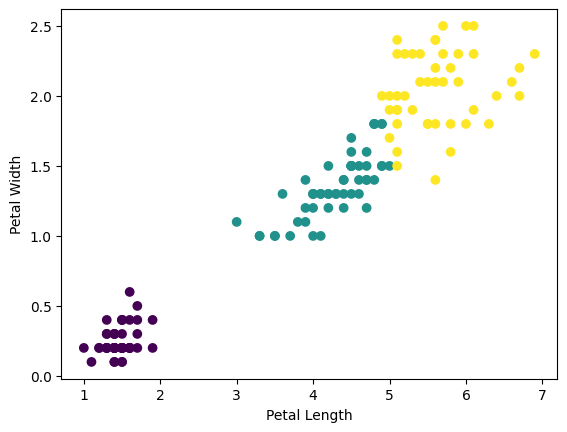

In [16]:
plt.scatter(df['petal length (cm)'],
            df['petal width (cm)'],
            c=df['cluster'])

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.show()

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
scaler = MinMaxScaler()

In [19]:
scaler.fit(df[['petal length (cm)']])
df['petal length (cm)'] = scaler.transform(df[['petal length (cm)']])

/tmp/ipykernel_2098/183312203.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['petal length (cm)'] = scaler.transform(df[['petal length (cm)']])


In [20]:
scaler.fit(df[['petal width (cm)']])
df['petal width (cm)'] = scaler.transform(df[['petal width (cm)']])

/tmp/ipykernel_2098/927047049.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['petal width (cm)'] = scaler.transform(df[['petal width (cm)']])


In [21]:
df.head()

,petal length (cm),petal width (cm),cluster
0,0.067797,0.041667,0
1,0.067797,0.041667,0
2,0.050847,0.041667,0
3,0.084746,0.041667,0
4,0.067797,0.041667,0


In [22]:
km = KMeans(n_clusters=3)

In [23]:
y_pred = km.fit_predict(df[['petal length (cm)', 'petal width (cm)']])

In [24]:
df['cluster'] = y_pred

/tmp/ipykernel_2098/2022102946.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = y_pred


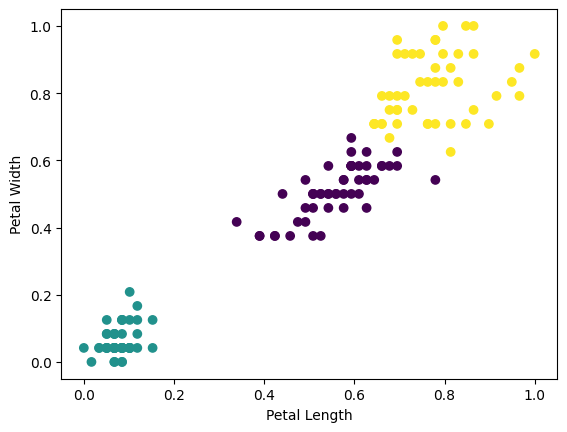

In [25]:
plt.scatter(df['petal length (cm)'],
            df['petal width (cm)'],
            c=df['cluster'])

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.show()

In [4]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df = df[['petal length (cm)', 'petal width (cm)']]
scaler = MinMaxScaler()
df['petal length (cm)'] = scaler.fit_transform(df[['petal length (cm)']])
df['petal width (cm)'] = scaler.fit_transform(df[['petal width (cm)']])
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k, random_state=0, n_init='auto')
    km.fit(df[['petal length (cm)', 'petal width (cm)']])
    sse.append(km.inertia_)

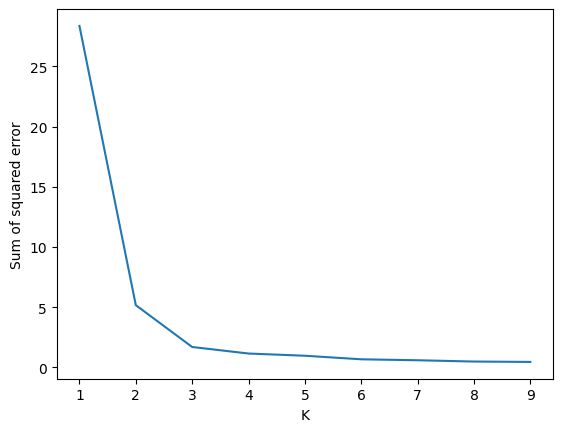

In [6]:
import matplotlib.pyplot as plt
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)

plt.show()

In [7]:
import joblib
joblib.dump(km, "kmeans_iris_model.pkl")

['kmeans_iris_model.pkl']